# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")
corpus = df["body"].fillna("")
corpus

0       we invoiced mirant americas for deal 705989 an...
1       because the payback was done for october 2001 ...
2       for december 1999 , since the volumes for tran...
3       i would think that the first contract should g...
4       welcome to the aol instant messenger ( sm ) se...
                              ...                        
1985    simply visti our site and let ' s see if we ca...
1986    order your medication here - no doctor visit n...
1987    wed , 09 jun 2004 13 : 33 : 18 - 0300\nsir or ...
1988    had chance at last to view the warner bros . l...
1989    while example milk . water , own , make , wire...
Name: body, Length: 1990, dtype: str

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


To clean the emails, lowercase the text, remove punctuation and numbers, and remove stop words. Then tokenize each email into words. Build a vocabulary of all unique words across all emails. For each email, count how many times each vocabulary word appears. Arrange these counts into a matrix where rows are emails and columns are vocabulary words.

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [2]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
tf_sparse = vectorizer.fit_transform(corpus)
tf_df = pd.DataFrame(tf_sparse.toarray(), columns=vectorizer.get_feature_names_out())
tf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


Document frequency is the number of documents in the corpus that contain a given word. IDF scales down the weight of words that appear in many documents and scales up the weight of words that appear in few documents. TF-IDF is preferred over TF because raw counts give high weight to common words that appear in almost every email even though they carry little information about a specific email's content. TF-IDF downweights these common words and upweights rarer, more distinctive words, giving a better representation of what makes each document unique.

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_sparse = tfidf_vectorizer.fit_transform(corpus)
tfidf_df = pd.DataFrame(tfidf_sparse.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11587,0.0
1986,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1987,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1988,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


In [4]:
known_mask = df["spam"].notna()

tf_known = tf_df[known_mask]
tfidf_known = tfidf_df[known_mask]
spam_known = df["spam"][known_mask]

word_counts = tf_known.sum(axis=1)
word_counts.groupby(spam_known).describe()

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0.0,995.0,135.327638,181.614139,0.0,28.0,74.0,174.5,1833.0
1.0,985.0,176.189848,271.308886,0.0,36.0,74.0,180.0,2594.0


<Axes: xlabel='spam'>

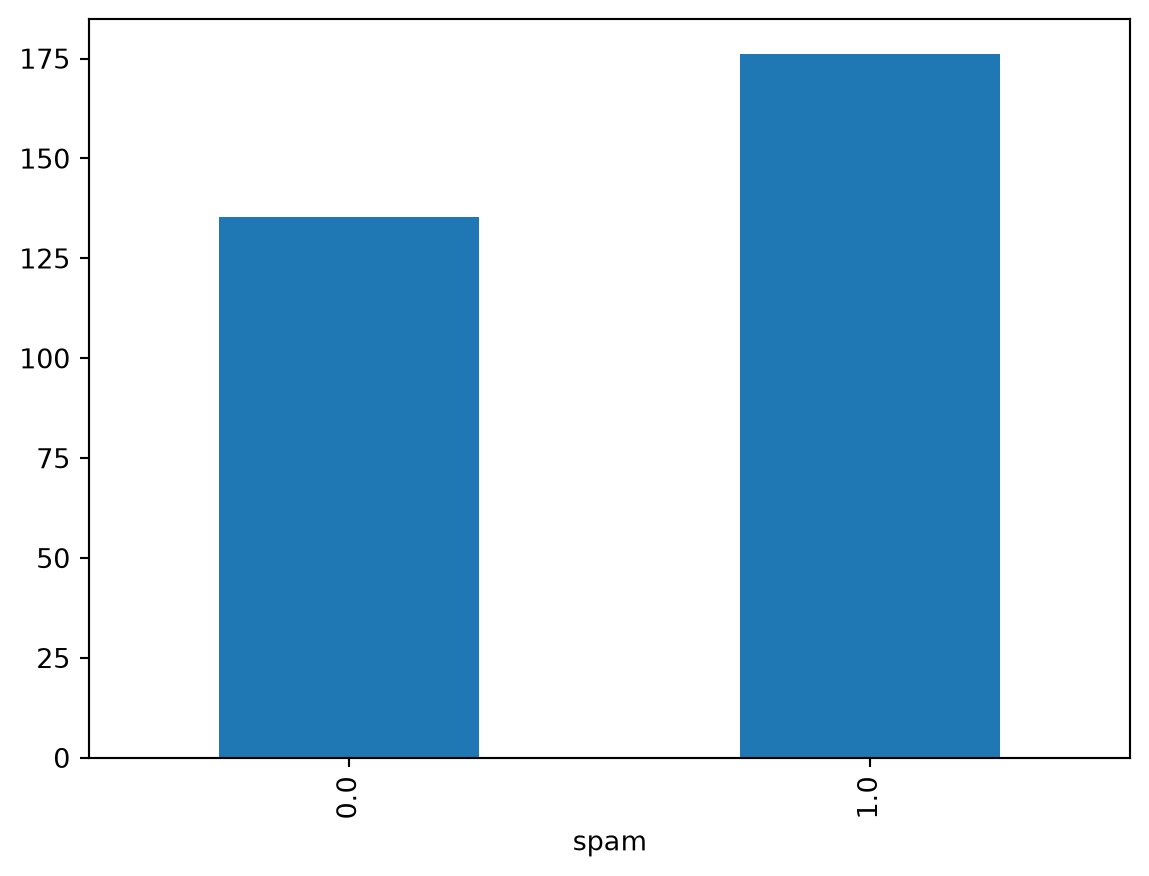

In [5]:
word_counts.groupby(spam_known).mean().plot(kind="bar")

In [6]:
tf_known.groupby(spam_known).mean().T.sort_values(1, ascending=False).head(10)

spam,0.0,1.0
the,4.795980,4.888325
to,3.958794,3.524873
and,1.950754,3.394924
of,1.468342,3.084264
in,1.182915,2.095431
you,1.292462,1.854822
for,1.875377,1.678173
this,1.300503,1.559391
is,1.298492,1.469036
your,0.472362,1.233503


In [7]:
tfidf_known.groupby(spam_known).mean().T.sort_values(1, ascending=False).head(10)

spam,0.0,1.0
the,0.082967,0.057534
to,0.065038,0.050273
and,0.034985,0.049189
you,0.029958,0.042117
of,0.028749,0.040379
your,0.011809,0.034473
in,0.024651,0.029420
for,0.038417,0.028624
is,0.030334,0.025543
this,0.029669,0.024971


7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

Compare each unknown email's TF or TF-IDF vector to the vectors of emails with known spam status, and find the known emails that are most similar. A distance metric such as cosine distance can measure similarity between rows of the TF or TF-IDF matrix. Then use the spam status of the most similar known emails to guess the spam status of the unknown email, which is similar to nearest neighbors approach.

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [8]:
from scipy.spatial.distance import cdist

unknown_tf = tf_df.loc[[1980]]
distances = cdist(unknown_tf, tf_known, metric="cosine")[0]
distances = pd.Series(distances, index=tf_known.index)
distances

0       0.736928
1       0.542990
2       0.775802
3       0.653954
4       0.519088
          ...   
1975    0.944996
1976    0.649040
1977    0.448669
1978    0.693219
1979    0.931826
Length: 1980, dtype: float64

9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [9]:
closest = distances.sort_values().head(10)
pd.concat([closest, spam_known[closest.index]], axis=1, keys=["distance", "spam"])

,distance,spam
1889,0.393060,1.0
1032,0.398488,1.0
1376,0.408606,1.0
714,0.414644,0.0
1110,0.415807,1.0
26,0.418573,0.0
180,0.423172,0.0
879,0.424620,0.0
713,0.427930,0.0
139,0.434841,0.0


The single closest known email (index 1889, distance 0.393) is spam. Among the 10 closest known emails, 5 are spam and 5 are not, close to a tie. Since the nearest neighbor is spam and sits at a noticeably smaller distance than the rest, I would guess the unknown email is spam, using the single nearest email as the tiebreaker.

10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

The results changes, but we would still guessd this email is spam, in both cases the majorty of the closes known emails are spam.

In [10]:
unknown_tfidf = tfidf_df.loc[[1980]]
distances_tfidf = cdist(unknown_tfidf, tfidf_known, metric="cosine")[0]
distances_tfidf = pd.Series(distances_tfidf, index=tfidf_known.index)

closest_tfidf = distances_tfidf.sort_values().head(10)
pd.concat([closest_tfidf, spam_known[closest_tfidf.index]], axis=1, keys=["distance", "spam"])

,distance,spam
1032,0.755245,1.0
1977,0.780917,1.0
48,0.787975,0.0
1689,0.790205,1.0
1796,0.795094,1.0
180,0.797415,0.0
586,0.798537,0.0
1376,0.799377,1.0
279,0.799969,0.0
1021,0.801259,1.0


11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [11]:
unknown_idx = df.index[~known_mask]
unknown_tfidf_all = tfidf_df.loc[unknown_idx]

all_distances = cdist(unknown_tfidf_all, tfidf_known, metric="cosine")
all_distances = pd.DataFrame(all_distances, index=unknown_idx, columns=tfidf_known.index)

guesses = {}
for idx in unknown_idx:
    nearest = all_distances.loc[idx].sort_values().head(5).index
    guesses[idx] = spam_known[nearest].mode()[0]

pd.Series(guesses, name="guessed_spam")

1980    1.0
1981    0.0
1982    0.0
1983    0.0
1984    0.0
1985    1.0
1986    1.0
1987    1.0
1988    1.0
1989    0.0
Name: guessed_spam, dtype: float64